In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from lawson_quant_library.data.yahoo_options import YahooOptionsAdapter
from lawson_quant_library.analytics.vol_surface import build_surface_points_from_adapter
from lawson_quant_library.viz.vol_surface import plot_surface_points_3d

In [3]:
as_of = pd.Timestamp.utcnow().tz_localize(None)
as_of

Timestamp('2026-03-01 22:51:01.853363')

In [4]:
benchmarks = {'SPX': 'SPY', 'NASDAQ': 'QQQ', 'Russel 2000': 'IWM', 'GOLD': 'GLD'}

In [5]:
surfaces = {}

for name, ticker in benchmarks.items():
    adapter = YahooOptionsAdapter(ticker=ticker)
    spot = adapter.spot()
    df = build_surface_points_from_adapter(adapter, ticker=ticker, as_of=as_of, spot=spot, option_type='call')
    print(name, ticker, df.shape)
    surfaces[name] = df

SPX SPY (2, 5)
NASDAQ QQQ (2, 5)
Russel 2000 IWM (2, 5)
GOLD GLD (2, 5)


In [6]:
surfaces

{'SPX': bucket       0.8       0.9       1.0       1.1       1.2
 tenor                                                   
 1D      0.819338  0.539067  0.156045  0.386725  0.710940
 1W      1.146977  0.576970  0.172249  0.273445  0.367194,
 'NASDAQ': bucket       0.8       0.9       1.0       1.1       1.2
 tenor                                                   
 1D      1.328128  0.954471  0.190804  0.384772  0.640629
 1W      0.655826  0.655826  0.218697  0.302741  0.302741,
 'Russel 2000': bucket       0.8       0.9       1.0       1.1       1.2
 tenor                                                   
 1D      1.798341  0.389655  0.220589  0.410162  0.625004
 1W      1.033694  0.000010  0.241341  0.306648  0.306648,
 'GOLD': bucket       0.8       0.9       1.0       1.1       1.2
 tenor                                                   
 1D      1.542971  0.621098  0.341071  0.511724  0.796877
 1W      1.121422  0.588139  0.359870  0.428879  0.668135}

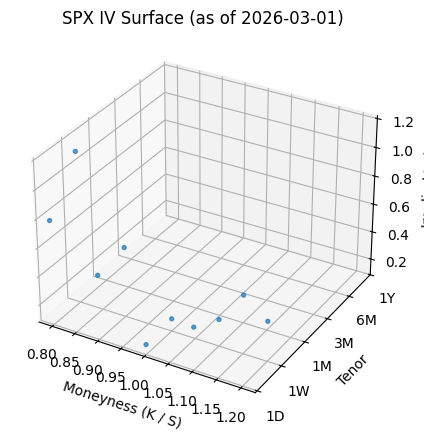

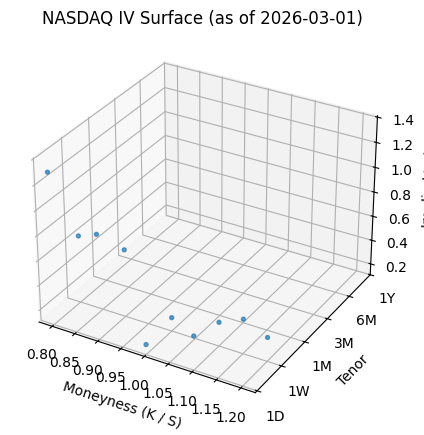

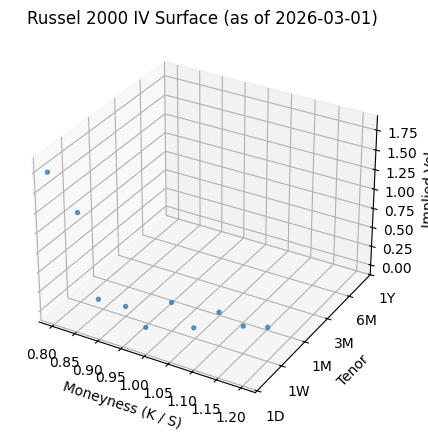

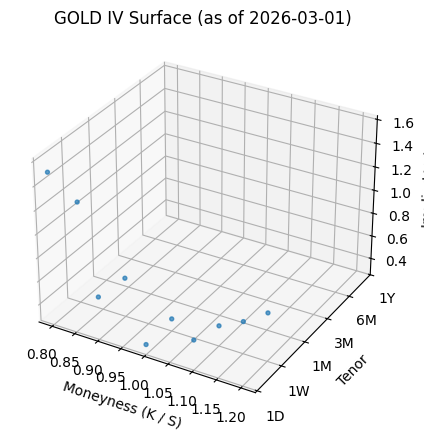

In [7]:
for name, df in surfaces.items():
    plot_surface_points_3d(df, title=f"{name} IV Surface (as of {as_of.date()})")
    plt.show()